# E4 — Real MNIST with a Controlled Acquisition Nuisance

**Paper question:** Does augmentation misalignment produce semantic-to-nuisance clustering failure on **real image content**, rather than only on the synthetic image generator used in E3?

> **Research-integrity note.** Run this notebook from a clean Kaggle session and save the exact Kaggle version used for the paper. Do not change seeds, thresholds, nuisance strength, corruption probabilities, or the lambda grid after inspecting the result. If this experiment fails its predeclared eligibility checks, report the failure and make a new, explicitly versioned experiment rather than tuning this run.

## Why MNIST here?

E1–E3 establish the mechanism under controlled mathematical and learned-image settings. E4 changes the semantic content to **real handwritten images** while keeping the nuisance fully controlled.

- **Semantic factor:** digit identity, restricted to 0 versus 1.
- **Nuisance factor:** a noisy acquisition-style left/right illumination gradient assigned independently of digit identity.
- **Misaligned augmentation:** foreground/digit evidence is strongly attenuated more often than the acquisition nuisance is reversed.
- **Aligned control:** the probabilities are reversed.

This is still a **controlled bridge experiment**, not a claim about patients, crops, or deployment. The purpose is to establish the mechanism on real image content before a welfare-facing application.

## Important methodological distinction

The augmentation generator knows the synthetic nuisance construction because we created it. Digit labels are **never used for representation learning, clustering, head selection, or augmentation**. Digit labels and nuisance group labels are used only for evaluation and prespecified sanity checks.

### Predeclared operating point

These numerical values are experimental operating points, **not universal thresholds**.

- nuisance evidence mean: `mu_N = 0.08`
- nuisance evidence noise: `sigma_N = 0.12`
- misaligned: `alpha = 0.25`, `q = 0.05`
- aligned: `alpha = 0.05`, `q = 0.25`
- corrupted foreground retains only 5% of its original strength
- lambda sweep: `0, 1, 2, 4, 8, 12, 16, 24, 32`

The broad theoretical statement remains about augmentation disagreement and semantic/nuisance preference, not these specific values.

## 0. Kaggle setup

This notebook uses `torchvision.datasets.MNIST`.

**Before running:** enable **Internet** in the Kaggle notebook settings so MNIST can be downloaded automatically. The notebook will stop with a clear message if the dataset is unavailable.

GPU is optional; the main representation is PCA and the clustering head is small.

In [1]:
from pathlib import Path
import json, sys, platform, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torchvision.datasets import MNIST
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import adjusted_rand_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OUT = Path("/kaggle/working/E4_real_mnist_controlled_nuisance")
OUT.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "experiment_id": "E4",
    "semantic_classes": [0, 1],
    "train_per_class": 2000,
    "test_per_class": 600,
    "seeds": [11, 22, 33],
    "pca_dim": 8,
    "nuisance_mu": 0.08,
    "nuisance_sigma": 0.12,
    "background_base": 0.12,
    "background_max": 0.30,
    "semantic_attenuation_when_corrupted": 0.05,
    "misaligned_alpha": 0.25,
    "misaligned_q": 0.05,
    "aligned_alpha": 0.05,
    "aligned_q": 0.25,
    "augmentation_views": 4,
    "lambda_grid": [0, 1, 2, 4, 8, 12, 16, 24, 32],
    "head_restarts": 3,
    "head_steps": 100,
    "head_lr": 0.03,
    "consistency_temperature": 0.35,
    "baseline_min_median_semantic_ari": 0.50,
    "baseline_max_median_nuisance_ari": 0.15,
}
(OUT / "config.json").write_text(json.dumps(CONFIG, indent=2))

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Device:", DEVICE)
print(json.dumps(CONFIG, indent=2))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.10.0+cpu
Device: cpu
{
  "experiment_id": "E4",
  "semantic_classes": [
    0,
    1
  ],
  "train_per_class": 2000,
  "test_per_class": 600,
  "seeds": [
    11,
    22,
    33
  ],
  "pca_dim": 8,
  "nuisance_mu": 0.08,
  "nuisance_sigma": 0.12,
  "background_base": 0.12,
  "background_max": 0.3,
  "semantic_attenuation_when_corrupted": 0.05,
  "misaligned_alpha": 0.25,
  "misaligned_q": 0.05,
  "aligned_alpha": 0.05,
  "aligned_q": 0.25,
  "augmentation_views": 4,
  "lambda_grid": [
    0,
    1,
    2,
    4,
    8,
    12,
    16,
    24,
    32
  ],
  "head_restarts": 3,
  "head_steps": 100,
  "head_lr": 0.03,
  "consistency_temperature": 0.35,
  "baseline_min_median_semantic_ari": 0.5,
  "baseline_max_median_nuisance_ari": 0.15
}


## 1. Load a fixed real-image semantic dataset

We use equal numbers of MNIST zeros and ones from the official train and test splits.

The class labels are retained only for held-out evaluation.

In [2]:
def load_mnist01():
    root = "/kaggle/working/mnist_data"
    try:
        tr = MNIST(root=root, train=True, download=True)
        te = MNIST(root=root, train=False, download=True)
    except Exception as e:
        raise RuntimeError(
            "MNIST could not be loaded. Enable Internet in Kaggle and rerun from a clean session."
        ) from e

    xtr = tr.data.numpy().astype(np.float32) / 255.0
    ytr = tr.targets.numpy().astype(int)
    xte = te.data.numpy().astype(np.float32) / 255.0
    yte = te.targets.numpy().astype(int)
    return xtr, ytr, xte, yte

XTRAIN_ALL, YTRAIN_ALL, XTEST_ALL, YTEST_ALL = load_mnist01()

def equal_class_subset(X, y, classes, per_class, seed):
    rng = np.random.default_rng(seed)
    selected = []
    for cls in classes:
        ids = np.where(y == cls)[0].copy()
        rng.shuffle(ids)
        if len(ids) < per_class:
            raise ValueError(f"Not enough examples for class {cls}: requested {per_class}.")
        selected.extend(ids[:per_class])
    selected = np.array(selected)
    rng.shuffle(selected)
    return X[selected], y[selected]

# One fixed semantic subset is used across seeds.
BASE_TRAIN, Y_TRAIN = equal_class_subset(
    XTRAIN_ALL, YTRAIN_ALL, CONFIG["semantic_classes"],
    CONFIG["train_per_class"], seed=2026
)
BASE_TEST, Y_TEST = equal_class_subset(
    XTEST_ALL, YTEST_ALL, CONFIG["semantic_classes"],
    CONFIG["test_per_class"], seed=2027
)

print("Train shape:", BASE_TRAIN.shape, "class counts:", np.bincount(Y_TRAIN))
print("Test shape:", BASE_TEST.shape, "class counts:", np.bincount(Y_TEST))

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 347kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.08MB/s]


Train shape: (4000, 28, 28) class counts: [2000 2000]
Test shape: (1200, 28, 28) class counts: [600 600]


## 2. Construct a lower-reliability acquisition nuisance independent of digit identity

For each semantic class separately, we assign exactly half the images to nuisance group \(N=-1\) and half to \(N=+1\). This makes the nuisance independent of digit identity **by construction**.

Observed nuisance evidence is noisy:

\[
g = \mu_N N + \sigma_N \epsilon,\qquad \epsilon\sim\mathcal N(0,1).
\]

The scalar \(g\) controls a left/right illumination gradient in the image background. Because \(\sigma_N>\mu_N\), the nuisance is intentionally imperfect and overlapping rather than an easy deterministic shortcut.

In [3]:
X_COORD = np.linspace(-1, 1, 28, dtype=np.float32)[None, None, :]

def balanced_nuisance_assignment(y, seed):
    rng = np.random.default_rng(seed)
    N = np.empty(len(y), dtype=np.int8)
    for cls in np.unique(y):
        ids = np.where(y == cls)[0].copy()
        rng.shuffle(ids)
        half = len(ids) // 2
        N[ids[:half]] = -1
        N[ids[half:]] = +1
    return N

def sample_nuisance_evidence(N, seed):
    rng = np.random.default_rng(seed)
    return (
        CONFIG["nuisance_mu"] * N.astype(np.float32)
        + CONFIG["nuisance_sigma"] * rng.normal(size=len(N)).astype(np.float32)
    )

def render_composite(base_digits, g):
    # Background illumination is visible mainly where the digit is absent.
    bg = CONFIG["background_base"] + g[:, None, None] * X_COORD
    bg = np.clip(bg, 0.0, CONFIG["background_max"])
    comp = base_digits + (1.0 - base_digits) * bg
    return np.clip(comp, 0.0, 1.0).astype(np.float32)

def correlation_binary(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    return float(np.corrcoef(a, b)[0, 1])

### Visual check

The four panels below are real MNIST digits overlaid with the controlled acquisition nuisance. The nuisance is deliberately subtle and noisy; it is not meant to visually dominate the digit.

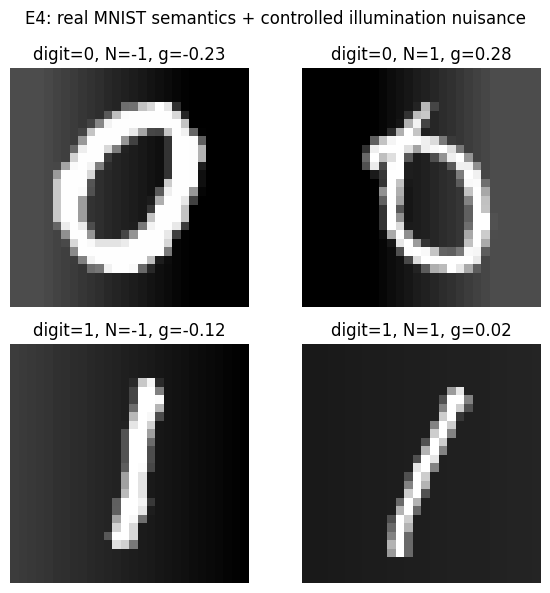

In [4]:
N_VIS = balanced_nuisance_assignment(Y_TRAIN, seed=999)
G_VIS = sample_nuisance_evidence(N_VIS, seed=1000)
X_VIS = render_composite(BASE_TRAIN, G_VIS)

fig, axes = plt.subplots(2, 2, figsize=(6, 6))
pairs = [(0, -1), (0, +1), (1, -1), (1, +1)]
for ax, (digit, nuisance) in zip(axes.ravel(), pairs):
    ids = np.where((Y_TRAIN == digit) & (N_VIS == nuisance))[0]
    # choose an example whose g sign agrees with its nuisance group, only for visualization
    agree = [i for i in ids if np.sign(G_VIS[i]) == nuisance]
    idx = agree[0] if agree else ids[0]
    ax.imshow(X_VIS[idx], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"digit={digit}, N={nuisance}, g={G_VIS[idx]:.2f}")
    ax.axis("off")
plt.suptitle("E4: real MNIST semantics + controlled illumination nuisance")
plt.tight_layout()
plt.savefig(OUT / "E4_real_mnist_examples.png", dpi=200)
plt.show()

## 3. Unsupervised representation: PCA on the composite images

E3 already established the mechanism with a CNN. E4's purpose is different: **real image content** with a controlled nuisance. To minimize additional optimization confounders, E4 uses an unsupervised PCA representation.

For each seed:

1. nuisance assignments/evidence are generated;
2. composite training images are rendered;
3. PCA is fit using training images only;
4. PCA coordinates are standardized using training statistics;
5. digit and nuisance labels are used only for diagnostic probes and evaluation.

The logistic probes below are diagnostics only; they never determine the clustering direction.

In [5]:
def build_seed_data(seed):
    Ntr = balanced_nuisance_assignment(Y_TRAIN, seed=10000 + seed)
    Nte = balanced_nuisance_assignment(Y_TEST, seed=20000 + seed)

    gtr = sample_nuisance_evidence(Ntr, seed=30000 + seed)
    gte = sample_nuisance_evidence(Nte, seed=40000 + seed)

    Xtr = render_composite(BASE_TRAIN, gtr)
    Xte = render_composite(BASE_TEST, gte)

    pca = PCA(
        n_components=CONFIG["pca_dim"],
        svd_solver="randomized",
        random_state=50000 + seed
    )
    ztr_raw = pca.fit_transform(Xtr.reshape(len(Xtr), -1))
    zte_raw = pca.transform(Xte.reshape(len(Xte), -1))

    mu = ztr_raw.mean(axis=0)
    sd = ztr_raw.std(axis=0)
    sd = np.maximum(sd, 1e-8)

    ztr = (ztr_raw - mu) / sd
    zte = (zte_raw - mu) / sd

    return {
        "seed": seed,
        "Ntr": Ntr, "Nte": Nte,
        "gtr": gtr, "gte": gte,
        "Xtr": Xtr, "Xte": Xte,
        "pca": pca, "mu": mu, "sd": sd,
        "ztr": ztr.astype(np.float32),
        "zte": zte.astype(np.float32),
    }

seed_data = {}
diag_rows = []

for seed in CONFIG["seeds"]:
    d = build_seed_data(seed)
    seed_data[seed] = d

    sem_probe = LogisticRegression(max_iter=2000, random_state=seed)
    sem_probe.fit(d["ztr"], Y_TRAIN)
    sem_probe_acc = sem_probe.score(d["zte"], Y_TEST)

    nui_probe = LogisticRegression(max_iter=2000, random_state=seed)
    nui_probe.fit(d["ztr"], d["Ntr"])
    nui_probe_acc = nui_probe.score(d["zte"], d["Nte"])

    diag_rows.append({
        "seed": seed,
        "corr_semantic_nuisance_train": correlation_binary(Y_TRAIN, d["Ntr"]),
        "corr_semantic_nuisance_test": correlation_binary(Y_TEST, d["Nte"]),
        "semantic_linear_probe_accuracy": sem_probe_acc,
        "nuisance_linear_probe_accuracy": nui_probe_acc,
        "pca_explained_variance_sum": float(d["pca"].explained_variance_ratio_.sum()),
    })

diagnostics = pd.DataFrame(diag_rows)
diagnostics.to_csv(OUT / "representation_diagnostics.csv", index=False)
diagnostics

,seed,corr_semantic_nuisance_train,corr_semantic_nuisance_test,semantic_linear_probe_accuracy,nuisance_linear_probe_accuracy,pca_explained_variance_sum
0,11,0.0,0.0,0.999167,0.766667,0.665915
1,22,0.0,0.0,0.999167,0.725000,0.665855
2,33,0.0,0.0,0.999167,0.750000,0.665807


## 4. Unsupervised projection clustering with label-free restart selection

The clustering head learns a unit-norm projection \(w\) of the standardized PCA representation.

For projected values \(y=w^\top z\), the base two-means distortion proxy is

\[
D(y)=E[y^2]-E[|y|]^2.
\]

The consistency loss compares differentiable sign assignments between original and augmented views.

### Important anti-cherry-picking safeguard

Each setting uses multiple random head initializations. The selected restart is the one with the **lowest unsupervised training objective**. Semantic and nuisance labels are not consulted for restart selection.

In [6]:
class ProjectionHead(nn.Module):
    def __init__(self, dim, seed):
        super().__init__()
        gen = torch.Generator(device="cpu")
        gen.manual_seed(int(seed))
        w0 = torch.randn(dim, generator=gen)
        self.w = nn.Parameter(w0.to(DEVICE))

    def normalized_w(self):
        return self.w / (self.w.norm() + 1e-8)

    def forward(self, z):
        return z @ self.normalized_w()

def cluster_loss(y):
    return (y * y).mean() - y.abs().mean() ** 2

def consistency_loss(y, ya):
    t = CONFIG["consistency_temperature"]
    return (
        (torch.tanh(y[None, :] / t) - torch.tanh(ya / t)) ** 2
    ).mean() / 4.0

def best_permutation_accuracy(pred_pm, target):
    target_pm = np.where(np.asarray(target) == 1, 1, -1)
    return float(max(
        np.mean(pred_pm == target_pm),
        np.mean(-pred_pm == target_pm)
    ))

def evaluate_clusters(pred_pm, semantic_y, nuisance_n):
    sem_acc = best_permutation_accuracy(pred_pm, semantic_y)
    nui_acc = best_permutation_accuracy(pred_pm, nuisance_n)

    pred_binary = (pred_pm > 0).astype(int)
    sem_ari = float(adjusted_rand_score(semantic_y, pred_binary))
    nui_ari = float(adjusted_rand_score(nuisance_n, pred_binary))

    return sem_acc, nui_acc, sem_ari, nui_ari

def fit_head(ztr, za_tr, lam, setting_seed):
    z = torch.tensor(ztr, dtype=torch.float32, device=DEVICE)
    za = None if za_tr is None else torch.tensor(
        za_tr, dtype=torch.float32, device=DEVICE
    )

    best = None
    for restart in range(CONFIG["head_restarts"]):
        seed = int(setting_seed + 997 * restart)
        torch.manual_seed(seed)

        head = ProjectionHead(CONFIG["pca_dim"], seed).to(DEVICE)
        opt = torch.optim.Adam(head.parameters(), lr=CONFIG["head_lr"])

        if za is not None:
            K, n, d = za.shape

        for _ in range(CONFIG["head_steps"]):
            y = head(z)
            loss = cluster_loss(y)

            if lam > 0:
                ya = (za.reshape(K * n, d) @ head.normalized_w()).reshape(K, n)
                loss = loss + lam * consistency_loss(y, ya)

            opt.zero_grad()
            loss.backward()
            opt.step()

        with torch.no_grad():
            y = head(z)
            final_obj = cluster_loss(y)
            if lam > 0:
                ya = (za.reshape(K * n, d) @ head.normalized_w()).reshape(K, n)
                final_obj = final_obj + lam * consistency_loss(y, ya)
            final_obj = float(final_obj.item())

        if best is None or final_obj < best["objective"]:
            best = {
                "objective": final_obj,
                "restart": restart,
                "head": head,
            }

    return best

## 5. Baseline eligibility gate — before testing augmentation misalignment

This is predeclared to prevent a misleading E4.

At \(\lambda=0\), the unsupervised clustering must already be predominantly semantic. Across seeds we require:

- median semantic ARI \(\ge 0.50\);
- median nuisance ARI \(\le 0.15\);
- median semantic ARI \(>\) median nuisance ARI.

If this gate fails, **stop**. Do not inspect or tune the augmentation result in this version.

In [7]:
baseline_rows = []

for seed in CONFIG["seeds"]:
    d = seed_data[seed]
    best = fit_head(
        d["ztr"], za_tr=None, lam=0,
        setting_seed=60000 + seed
    )

    head = best["head"]
    with torch.no_grad():
        zte_t = torch.tensor(d["zte"], dtype=torch.float32, device=DEVICE)
        pred = torch.where(head(zte_t) >= 0, 1, -1).cpu().numpy()

    sem_acc, nui_acc, sem_ari, nui_ari = evaluate_clusters(
        pred, Y_TEST, d["Nte"]
    )

    baseline_rows.append({
        "seed": seed,
        "selected_restart": best["restart"],
        "training_objective": best["objective"],
        "semantic_accuracy": sem_acc,
        "nuisance_accuracy": nui_acc,
        "semantic_ari": sem_ari,
        "nuisance_ari": nui_ari,
    })

baseline = pd.DataFrame(baseline_rows)
baseline.to_csv(OUT / "baseline_lambda0_runs.csv", index=False)
display(baseline)

median_sem_ari = float(baseline["semantic_ari"].median())
median_nui_ari = float(baseline["nuisance_ari"].median())

BASELINE_ELIGIBLE = (
    median_sem_ari >= CONFIG["baseline_min_median_semantic_ari"]
    and median_nui_ari <= CONFIG["baseline_max_median_nuisance_ari"]
    and median_sem_ari > median_nui_ari
)

print("Median semantic ARI:", median_sem_ari)
print("Median nuisance ARI:", median_nui_ari)
print("BASELINE_ELIGIBLE =", BASELINE_ELIGIBLE)

if not BASELINE_ELIGIBLE:
    raise RuntimeError(
        "STOP: E4 baseline is not predominantly semantic. "
        "Do not interpret augmentation results or tune parameters in this notebook version."
    )

,seed,selected_restart,training_objective,semantic_accuracy,nuisance_accuracy,semantic_ari,nuisance_ari
0,11,0,0.212272,0.667500,0.512500,0.111487,-0.000205
1,22,0,0.209281,0.564167,0.505833,0.015652,-0.000695
2,33,0,0.079254,0.996667,0.501667,0.986700,-0.000824


Median semantic ARI: 0.1114874155760861
Median nuisance ARI: -0.0006949706523595756
BASELINE_ELIGIBLE = False


RuntimeError: STOP: E4 baseline is not predominantly semantic. Do not interpret augmentation results or tune parameters in this notebook version.

## 6. Sample actual image augmentations

### Semantic-evidence corruption

With probability \(\alpha\), the digit foreground is strongly attenuated to 5% of its original intensity. This is deliberately a **semantic-evidence dropout stress test**. It is not presented as a recommended augmentation.

### Nuisance corruption

With probability \(q\), the observed illumination gradient coefficient is reversed, \(g\mapsto-g\).

The underlying digit label and nuisance group remain fixed; only their observed evidence is perturbed.

Misaligned condition:
\[
\alpha=0.25>q=0.05.
\]

Aligned control:
\[
\alpha=0.05<q=0.25.
\]

In [8]:
def generate_augmented_features(d, base_digits, alpha, q, seed, split="train"):
    rng = np.random.default_rng(seed)

    if split == "train":
        g0 = d["gtr"]
    else:
        g0 = d["gte"]

    views = []
    for _ in range(CONFIG["augmentation_views"]):
        sem_corrupt = rng.random(len(base_digits)) < alpha
        nui_corrupt = rng.random(len(base_digits)) < q

        base_aug = base_digits.copy()
        base_aug[sem_corrupt] *= CONFIG["semantic_attenuation_when_corrupted"]

        g_aug = g0.copy()
        g_aug[nui_corrupt] *= -1.0

        X_aug = render_composite(base_aug, g_aug)
        z_raw = d["pca"].transform(X_aug.reshape(len(X_aug), -1))
        z = (z_raw - d["mu"]) / d["sd"]
        views.append(z.astype(np.float32))

    return np.stack(views, axis=0)

augmented = {}
for seed in CONFIG["seeds"]:
    d = seed_data[seed]
    augmented[seed] = {}

    for condition, alpha, q, offset in [
        ("misaligned", CONFIG["misaligned_alpha"], CONFIG["misaligned_q"], 0),
        ("aligned", CONFIG["aligned_alpha"], CONFIG["aligned_q"], 100000),
    ]:
        za_tr = generate_augmented_features(
            d, BASE_TRAIN, alpha, q,
            seed=70000 + seed + offset, split="train"
        )
        za_te = generate_augmented_features(
            d, BASE_TEST, alpha, q,
            seed=80000 + seed + offset, split="test"
        )
        augmented[seed][condition] = (za_tr, za_te)

print("Augmented feature tensors prepared.")

Augmented feature tensors prepared.


## 7. Main E4 sweep

Primary clustering metrics:

- semantic ARI;
- nuisance ARI.

A solution is called **nuisance-dominated** when nuisance ARI exceeds semantic ARI. This avoids importing the angle-based \(80^\circ\) reporting threshold from E1–E3 into a high-dimensional real-image representation.

We also report best-permutation accuracies and held-out augmentation agreement.

In [9]:
def heldout_agreement(head, zte, za_te):
    with torch.no_grad():
        z = torch.tensor(zte, dtype=torch.float32, device=DEVICE)
        za = torch.tensor(za_te, dtype=torch.float32, device=DEVICE)

        y = head(z)
        K, n, d = za.shape
        ya = (za.reshape(K*n, d) @ head.normalized_w()).reshape(K, n)

        p = torch.where(y >= 0, 1, -1)
        pa = torch.where(ya >= 0, 1, -1)

        return float((pa == p[None, :]).float().mean().item())

run_rows = []

for seed in CONFIG["seeds"]:
    d = seed_data[seed]

    for condition, offset in [("misaligned", 0), ("aligned", 200000)]:
        za_tr, za_te = augmented[seed][condition]

        for lam in CONFIG["lambda_grid"]:
            if lam == 0:
                # Refit with the same label-free procedure rather than copying a label-informed result.
                za_for_fit = None
            else:
                za_for_fit = za_tr

            best = fit_head(
                d["ztr"], za_for_fit, lam,
                setting_seed=90000 + seed + offset + int(lam * 101)
            )

            head = best["head"]

            with torch.no_grad():
                zte_t = torch.tensor(d["zte"], dtype=torch.float32, device=DEVICE)
                pred = torch.where(head(zte_t) >= 0, 1, -1).cpu().numpy()

            sem_acc, nui_acc, sem_ari, nui_ari = evaluate_clusters(
                pred, Y_TEST, d["Nte"]
            )

            agreement = (
                np.nan if lam == 0
                else heldout_agreement(head, d["zte"], za_te)
            )

            run_rows.append({
                "condition": condition,
                "seed": seed,
                "lambda": lam,
                "selected_restart": best["restart"],
                "training_objective": best["objective"],
                "semantic_accuracy": sem_acc,
                "nuisance_accuracy": nui_acc,
                "semantic_ari": sem_ari,
                "nuisance_ari": nui_ari,
                "nuisance_dominated": float(nui_ari > sem_ari),
                "augmentation_agreement": agreement,
            })

runs = pd.DataFrame(run_rows)
runs.to_csv(OUT / "E4_seed_level_runs.csv", index=False)

summary = runs.groupby(["condition", "lambda"]).agg(
    median_semantic_accuracy=("semantic_accuracy", "median"),
    median_nuisance_accuracy=("nuisance_accuracy", "median"),
    median_semantic_ari=("semantic_ari", "median"),
    median_nuisance_ari=("nuisance_ari", "median"),
    p_nuisance_dominated=("nuisance_dominated", "mean"),
    median_augmentation_agreement=("augmentation_agreement", "median"),
).reset_index()

summary.to_csv(OUT / "E4_summary.csv", index=False)
summary

,condition,lambda,median_semantic_accuracy,median_nuisance_accuracy,median_semantic_ari,median_nuisance_ari,p_nuisance_dominated,median_augmentation_agreement
0,aligned,0,0.612500,0.514167,0.049833,-0.000031,0.000000,NaN
1,aligned,1,0.996667,0.500000,0.986700,-0.000835,0.000000,0.981458
2,aligned,2,0.566667,0.506667,0.016958,-0.000657,0.333333,0.993750
3,aligned,4,0.996667,0.501667,0.986700,-0.000824,0.000000,0.998750
4,aligned,8,0.629167,0.515833,0.065959,0.000170,0.000000,0.986875
5,aligned,12,0.697500,0.505833,0.155321,-0.000698,0.000000,0.994583
6,aligned,16,0.690000,0.508333,0.143688,-0.000556,0.000000,0.996250
7,aligned,24,0.643333,0.507500,0.081412,-0.000608,0.000000,0.995625
8,aligned,32,0.698333,0.505833,0.156643,-0.000697,0.000000,0.994167
9,misaligned,0,0.996667,0.500000,0.986700,-0.000834,0.000000,NaN


## 8. Paper-facing figures

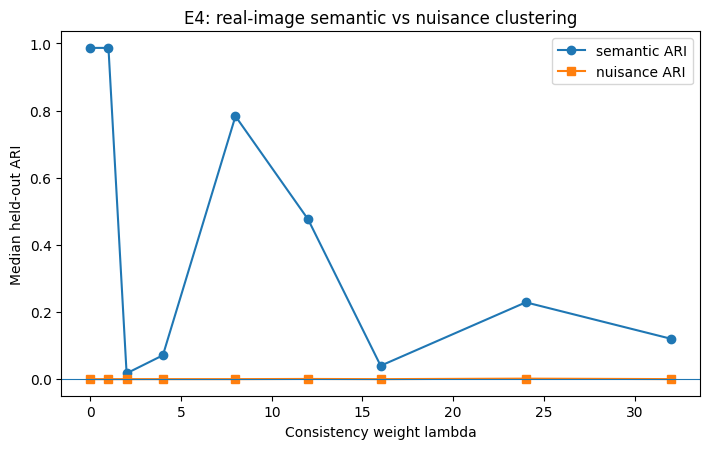

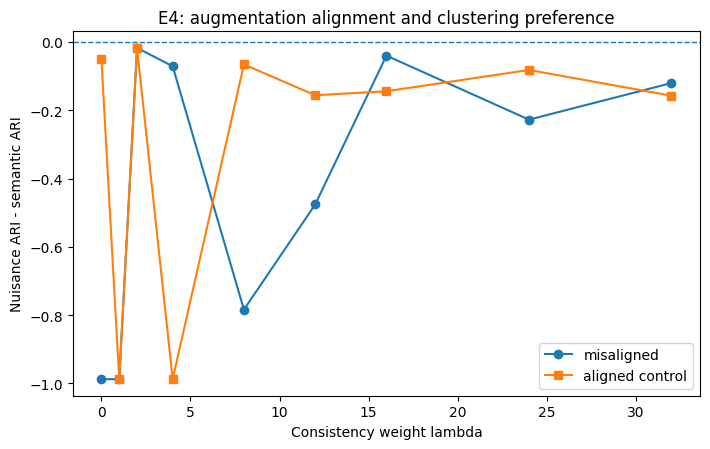

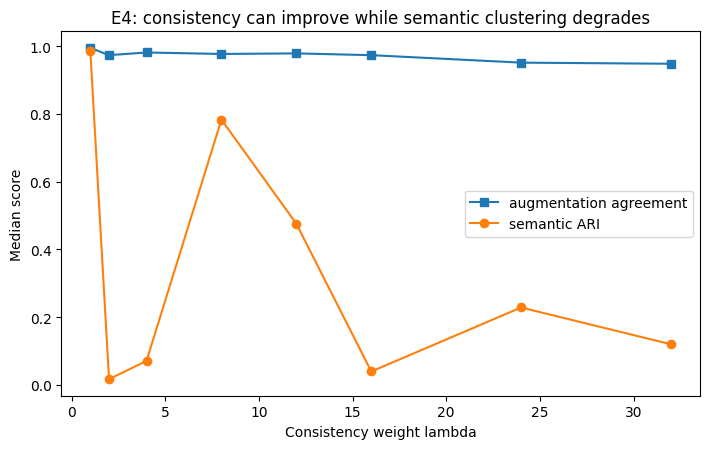

In [10]:
mis = summary[summary["condition"] == "misaligned"]
ali = summary[summary["condition"] == "aligned"]

plt.figure(figsize=(7.2, 4.6))
plt.plot(mis["lambda"], mis["median_semantic_ari"], marker="o", label="semantic ARI")
plt.plot(mis["lambda"], mis["median_nuisance_ari"], marker="s", label="nuisance ARI")
plt.axhline(0, linewidth=0.8)
plt.xlabel("Consistency weight lambda")
plt.ylabel("Median held-out ARI")
plt.title("E4: real-image semantic vs nuisance clustering")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "E4_semantic_vs_nuisance_ari.png", dpi=200)
plt.show()

plt.figure(figsize=(7.2, 4.6))
plt.plot(
    mis["lambda"],
    mis["median_nuisance_ari"] - mis["median_semantic_ari"],
    marker="o", label="misaligned"
)
plt.plot(
    ali["lambda"],
    ali["median_nuisance_ari"] - ali["median_semantic_ari"],
    marker="s", label="aligned control"
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Consistency weight lambda")
plt.ylabel("Nuisance ARI - semantic ARI")
plt.title("E4: augmentation alignment and clustering preference")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "E4_alignment_gap.png", dpi=200)
plt.show()

mis_agree = mis.dropna(subset=["median_augmentation_agreement"])
plt.figure(figsize=(7.2, 4.6))
plt.plot(
    mis_agree["lambda"], mis_agree["median_augmentation_agreement"],
    marker="s", label="augmentation agreement"
)
plt.plot(
    mis_agree["lambda"], mis_agree["median_semantic_ari"],
    marker="o", label="semantic ARI"
)
plt.xlabel("Consistency weight lambda")
plt.ylabel("Median score")
plt.title("E4: consistency can improve while semantic clustering degrades")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "E4_agreement_vs_semantic_ari.png", dpi=200)
plt.show()

## 9. Predeclared final interpretation checks

E4 is considered a **successful real-image mechanism replication** only if all of the following hold:

1. the nuisance is independent of semantic class by construction;
2. the \(\lambda=0\) clustering is predominantly semantic;
3. there exists at least one tested \(\lambda>0\) where the **median** misaligned nuisance ARI exceeds the median semantic ARI;
4. at the maximum tested aligned-control \(\lambda\), semantic ARI remains at least as large as nuisance ARI;
5. all predeclared seeds are present.

If condition 3 fails, E4 is a negative result. Do **not** change the lambda grid or corruption parameters inside this saved version simply to make it pass.

In [11]:
max_lam = max(CONFIG["lambda_grid"])
mis_pos = mis[mis["lambda"] > 0]
ali_max = ali[ali["lambda"] == max_lam].iloc[0]

checks = {
    "nuisance_independent_of_semantics_train": bool(
        diagnostics["corr_semantic_nuisance_train"].abs().max() < 1e-8
    ),
    "nuisance_independent_of_semantics_test": bool(
        diagnostics["corr_semantic_nuisance_test"].abs().max() < 1e-8
    ),
    "baseline_predominantly_semantic": bool(BASELINE_ELIGIBLE),
    "misaligned_has_median_nuisance_preference": bool(
        (mis_pos["median_nuisance_ari"] > mis_pos["median_semantic_ari"]).any()
    ),
    "aligned_max_lambda_not_nuisance_preferred": bool(
        ali_max["median_semantic_ari"] >= ali_max["median_nuisance_ari"]
    ),
    "all_declared_seeds_present": bool(
        runs["seed"].nunique() == len(CONFIG["seeds"])
    ),
}

print(checks)
(OUT / "sanity_checks.json").write_text(json.dumps(checks, indent=2))

passed = all(checks.values())
print("\nE4 PAPER-ELIGIBLE:", passed)

if passed:
    print("E4 passed the predeclared real-image mechanism replication checks.")
else:
    print(
        "E4 did NOT pass all predeclared checks. Preserve this run as a negative/partial result; "
        "do not tune this saved version post hoc."
    )

{'nuisance_independent_of_semantics_train': True, 'nuisance_independent_of_semantics_test': True, 'baseline_predominantly_semantic': False, 'misaligned_has_median_nuisance_preference': False, 'aligned_max_lambda_not_nuisance_preferred': True, 'all_declared_seeds_present': True}

E4 PAPER-ELIGIBLE: False
E4 did NOT pass all predeclared checks. Preserve this run as a negative/partial result; do not tune this saved version post hoc.


## 10. Save a compact run manifest

Keep the Kaggle notebook version, the output directory, and these files together:

- `config.json`
- `representation_diagnostics.csv`
- `baseline_lambda0_runs.csv`
- `E4_seed_level_runs.csv`
- `E4_summary.csv`
- `sanity_checks.json`
- all three E4 figures

In [12]:
manifest = {
    "experiment": "E4_real_mnist_controlled_nuisance",
    "paper_facing_name": "Real-Image Controlled Nuisance Validation",
    "dataset": "MNIST digits 0 and 1",
    "representation": f"PCA-{CONFIG['pca_dim']} standardized using training data only",
    "semantic_training_labels_used": False,
    "restart_selection_uses_labels": False,
    "nuisance_is_synthetic_and_balanced_within_class": True,
    "device": str(DEVICE),
    "python_version": sys.version,
    "torch_version": torch.__version__,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
}
(OUT / "run_manifest.json").write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))
print("\nE4 notebook complete. Save this exact Kaggle version and download the entire output folder.")

{
  "experiment": "E4_real_mnist_controlled_nuisance",
  "paper_facing_name": "Real-Image Controlled Nuisance Validation",
  "dataset": "MNIST digits 0 and 1",
  "representation": "PCA-8 standardized using training data only",
  "semantic_training_labels_used": false,
  "restart_selection_uses_labels": false,
  "nuisance_is_synthetic_and_balanced_within_class": true,
  "device": "cpu",
  "python_version": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "torch_version": "2.10.0+cpu",
  "numpy_version": "2.0.2",
  "pandas_version": "2.3.3"
}

E4 notebook complete. Save this exact Kaggle version and download the entire output folder.
